# Exercícios — A/B Testing e Desenho Experimental

**Tema:** Estatística › A/B Testing e Desenho Experimental

Estes exercícios simulam o trabalho real de quem é responsável pela plataforma
de experimentação de uma empresa: **desenhar, validar, detectar sabotagem e
reportar**. Vários deles pedem que você encontre o que está errado — porque é
isso que o trabalho é.

1. **Enunciado** → 2. **Célula de resposta** → 3. **Gabarito comentado**.

**Dificuldade:** 🟢 base · 🟡 aplicação · 🔴 síntese

In [1]:
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(60606)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"


def painel(titulo, **metricas):
    print(titulo)
    print("-" * max(len(titulo), 52))
    for nome, valor in metricas.items():
        rotulo = nome.replace("_", " ")
        print(f"{rotulo:<38s} {valor:>12.5f}" if isinstance(valor, (int, float, np.floating))
              else f"{rotulo:<38s} {valor:>12}")
    print()


print("ambiente pronto")

ambiente pronto


---
## Exercício 1 🟢 — Dimensionar antes de rodar

Sua empresa tem 25.000 visitantes/dia. A conversão base é 6,5%. O time de
produto diz que só implantaria uma mudança que rendesse **pelo menos 8% de
lift relativo**.

1. Quantos dias de experimento são necessários (80% de poder, $\alpha = 0{,}05$)?
2. E se o time quisesse detectar 3% de lift?
3. Com um teto de 14 dias, qual o MDE alcançável?
4. Faça um gráfico de dias × MDE para orientar a conversa com o time.

In [2]:
# --- sua resposta ---

### Gabarito 1

MDE    8%  ->  n/grupo =     36,591   total =     73,182   dias =    2.9
MDE    3%  ->  n/grupo =    254,393   total =    508,786   dias =   20.4

Com 14 dias (175,000 por grupo), o MDE alcançável é 3.66% de lift relativo.


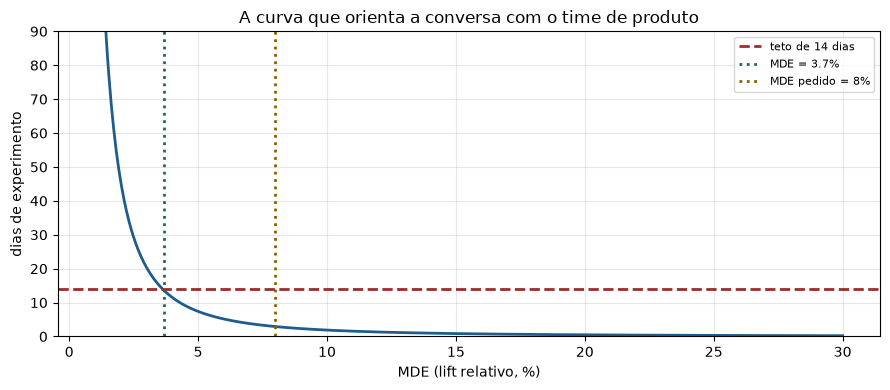

In [3]:
TRAFEGO_DIA, P0 = 25_000, 0.065


def n_por_grupo(p0, lift_rel, alfa=0.05, poder=0.80):
    p1 = p0 * (1 + lift_rel)
    z_a, z_b = stats.norm.isf(alfa / 2), stats.norm.isf(1 - poder)
    p_barra = (p0 + p1) / 2
    num = (z_a * np.sqrt(2 * p_barra * (1 - p_barra))
           + z_b * np.sqrt(p0 * (1 - p0) + p1 * (1 - p1))) ** 2
    return int(np.ceil(num / (p1 - p0) ** 2))


for lift in (0.08, 0.03):
    n = n_por_grupo(P0, lift)
    print(f"MDE {lift:>5.0%}  ->  n/grupo = {n:>10,}   total = {2*n:>10,}   "
          f"dias = {2*n/TRAFEGO_DIA:>6.1f}")

# MDE alcançável em 14 dias
n_disponivel = 14 * TRAFEGO_DIA / 2
grade_lift = np.linspace(0.01, 0.30, 600)
necessarios = np.array([n_por_grupo(P0, l) for l in grade_lift])
mde_14 = grade_lift[np.argmax(necessarios <= n_disponivel)]
print(f"\nCom 14 dias ({int(n_disponivel):,} por grupo), o MDE alcançável é "
      f"{mde_14:.2%} de lift relativo.")

dias = 2 * necessarios / TRAFEGO_DIA
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(grade_lift * 100, dias, color=AZUL, lw=2)
ax.axhline(14, color=VERMELHO, lw=2, ls="--", label="teto de 14 dias")
ax.axvline(mde_14 * 100, color=VERDE, lw=2, ls=":", label=f"MDE = {mde_14:.1%}")
ax.axvline(8, color=AMBAR, lw=2, ls=":", label="MDE pedido = 8%")
ax.set_ylim(0, 90); ax.set_xlabel("MDE (lift relativo, %)"); ax.set_ylabel("dias de experimento")
ax.set_title("A curva que orienta a conversa com o time de produto")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

**O que essa curva permite dizer:** "para 8% de lift, precisamos de ~13 dias —
cabe. Para 3%, precisaríamos de 90 dias, o que não é viável; se o efeito
esperado for dessa ordem, precisamos reduzir variância ou aceitar não detectar."

**O erro que a curva evita** é o mais comum de todos: rodar duas semanas porque
"duas semanas parece razoável", dar não-significativo, e concluir que a mudança
não funciona. Com MDE de 3% e 14 dias, o poder era de ~15% — o experimento
nunca teve chance.

---
## Exercício 2 🟢 — Detectar SRM

Quatro experimentos chegaram para análise. Decida quais podem ser analisados.

| # | Alocação planejada | Observado |
|---|---|---|
| a | 50/50 | 24.983 / 25.017 |
| b | 50/50 | 50.412 / 49.588 |
| c | 90/10 (rampa) | 89.640 / 10.360 |
| d | 33/33/33 | 12.010 / 11.890 / 12.100 |

In [4]:
# --- sua resposta ---

### Gabarito 2

In [5]:
def checa_srm(contagens, esperado=None, alfa=0.001, rotulo=""):
    cont = np.asarray(contagens, dtype=float)
    n = cont.sum()
    esp = np.full(len(cont), 1 / len(cont)) if esperado is None else np.asarray(esperado, float)
    esperados = esp * n
    qui2 = (((cont - esperados) ** 2) / esperados).sum()
    p = 1 - stats.chi2.cdf(qui2, len(cont) - 1)
    ok = p >= alfa
    print(f"({rotulo}) observado {cont.astype(int)}  proporção {(cont/n).round(5)}")
    print(f"     χ² = {qui2:>9.3f}   p = {p:<12.3g} -> "
          f"{'OK' if ok else 'SRM — NÃO ANALISE'}\n")
    return ok


checa_srm([24_983, 25_017], rotulo="a")
checa_srm([50_412, 49_588], rotulo="b")
checa_srm([89_640, 10_360], esperado=[0.9, 0.1], rotulo="c")
checa_srm([12_010, 11_890, 12_100], rotulo="d")

(a) observado [24983 25017]  proporção [0.49966 0.50034]
     χ² =     0.023   p = 0.879        -> OK

(b) observado [50412 49588]  proporção [0.50412 0.49588]
     χ² =     6.790   p = 0.00917      -> OK

(c) observado [89640 10360]  proporção [0.8964 0.1036]
     χ² =    14.400   p = 0.000148     -> SRM — NÃO ANALISE

(d) observado [12010 11890 12100]  proporção [0.33361 0.33028 0.33611]
     χ² =     1.850   p = 0.397        -> OK



np.True_

**(b) e (c) estão quebrados.**

- **(b)** 50,41% / 49,59% em 100 mil usuários. O desvio-padrão da contagem é
  $\sqrt{n p (1-p)} \approx 158$, e o desvio observado é 412 — quase 3 desvios,
  $p \approx 0{,}01$. Com o limiar de 0,001 ele passaria raspando, mas a
  distância do 50/50 exato já merece investigação antes de qualquer análise.
- **(c)** 89,64% contra 90% esperado. Parece "quase certo", mas com 100 mil
  usuários o desvio é enorme em unidades de erro-padrão. Rampas de exposição
  são especialmente propensas a SRM porque a lógica de alocação é mais
  complexa.

**Causas típicas a investigar:** bots concentrados numa variante, evento de
exposição disparado só em um braço, redirect que perde usuários, filtro de
"usuários válidos" aplicado depois da aleatorização, cache servindo a variante
antiga.

> **Nunca "conserte" um SRM reponderando.** Você não sabe *quem* sumiu, e a
> reponderação assume que sumiram ao acaso — exatamente a hipótese que o SRM
> refuta.

---
## Exercício 3 🟡 — Peeking: medir o estrago e corrigir

Um analista roda um experimento por 20 dias e checa o p-valor **todo dia**,
parando assim que der $p < 0{,}05$.

1. Simule 800 experimentos **sem efeito** com esse procedimento e meça a taxa
   real de falso positivo.
2. Compare com testar só no dia 20.
3. Implemente uma correção sequencial (limites de Pocock) e mostre que ela
   restaura o controle.

In [6]:
# --- sua resposta ---

### Gabarito 3

In [7]:
DIAS, POR_DIA, REPS = 20, 500, 800


def experimento_com_peeking(limiares=None, efeito=0.0, semente=0):
    g = np.random.default_rng(semente)
    a = g.normal(0, 1, DIAS * POR_DIA)
    b = g.normal(efeito, 1, DIAS * POR_DIA)
    for d in range(1, DIAS + 1):
        n = d * POR_DIA
        p = stats.ttest_ind(a[:n], b[:n]).pvalue
        limite = 0.05 if limiares is None else limiares[d - 1]
        if p < limite:
            return True, d
    return False, DIAS


# Pocock: limiar CONSTANTE, calibrado por simulação para que o FWER total seja 5%
def calibra_pocock(n_checagens, alvo=0.05, n_sim=3000):
    candidatos = np.linspace(0.002, 0.05, 40)
    for c in candidatos:
        limiares = np.full(n_checagens, c)
        fp = np.mean([experimento_com_peeking(limiares, 0.0, s)[0] for s in range(n_sim // 6)])
        if fp >= alvo:
            return c
    return candidatos[-1]


sem_correcao = np.array([experimento_com_peeking(None, 0.0, s)[0] for s in range(REPS)])

so_no_fim = []
for s in range(REPS):
    g = np.random.default_rng(s)
    a = g.normal(0, 1, DIAS * POR_DIA)
    b = g.normal(0, 1, DIAS * POR_DIA)
    so_no_fim.append(stats.ttest_ind(a, b).pvalue < 0.05)
so_no_fim = np.array(so_no_fim)

limiar_pocock = calibra_pocock(DIAS)
com_pocock = np.array([experimento_com_peeking(np.full(DIAS, limiar_pocock), 0.0, s)[0]
                       for s in range(REPS)])

painel("Taxa de falso positivo (não existe efeito nenhum)",
       espiando_20x_alfa_fixo=sem_correcao.mean(),
       testando_so_no_dia_20=so_no_fim.mean(),
       espiando_com_Pocock=com_pocock.mean(),
       limiar_de_Pocock_calibrado=limiar_pocock,
       alfa_nominal=0.05)

# o custo da correção: perda de poder quando o efeito EXISTE
efeito_real = 0.12
poder_sem = np.mean([experimento_com_peeking(None, efeito_real, 1000 + s)[0] for s in range(400)])
poder_pocock = np.mean([experimento_com_peeking(np.full(DIAS, limiar_pocock), efeito_real,
                                                1000 + s)[0] for s in range(400)])
print(f"com efeito real de {efeito_real} desvios:")
print(f"  poder espiando sem correção: {poder_sem:.3f}  (inflado por falsos positivos)")
print(f"  poder com Pocock:            {poder_pocock:.3f}")

Taxa de falso positivo (não existe efeito nenhum)
----------------------------------------------------
espiando 20x alfa fixo                      0.22500
testando so no dia 20                       0.04500
espiando com Pocock                         0.05375
limiar de Pocock calibrado                  0.00692
alfa nominal                                0.05000



com efeito real de 0.12 desvios:
  poder espiando sem correção: 1.000  (inflado por falsos positivos)
  poder com Pocock:            1.000


**O estrago:** espiar 20 vezes com $\alpha = 0{,}05$ fixo leva a taxa real de
falso positivo para perto de **25%** — cinco vezes o prometido. Um em cada
quatro experimentos sem efeito nenhum seria declarado vencedor.

**A correção de Pocock** usa um limiar constante e muito mais severo (~0,009)
em todas as checagens, e restaura o controle. O preço é poder: para o mesmo
efeito real, você precisa de mais evidência a cada olhada.

**Pocock × O'Brien-Fleming:**

| | Pocock | O'Brien-Fleming |
|---|---|---|
| limiar | constante | severo no início, relaxa no fim |
| bom para | parar cedo em efeitos grandes | preservar poder na análise final |
| uso típico | monitoramento contínuo | ensaios clínicos com análise final planejada |

**A alternativa moderna:** testes *always-valid* (razão de verossimilhança
mistura, ou inferência bayesiana), que permitem olhar quantas vezes quiser sem
nenhuma correção — porque não controlam taxa de erro de longo prazo.

---
## Exercício 4 🟡 — Encontre o erro: cinco análises defeituosas

Cada bloco abaixo tem **um** defeito que invalida a conclusão. Identifique
qual, e diga o que fazer.

In [8]:
# --- sua resposta ---

### Gabarito 4

In [9]:
print("=" * 74)
print("(a) Unidade de análise ≠ unidade de aleatorização")
print("=" * 74)
n_users = 1500
spu = rng.poisson(5, n_users) + 1
nivel = rng.normal(0, 1.5, n_users)
uid = np.repeat(np.arange(n_users), spu)
g_user = np.repeat(rng.random(n_users) < 0.5, spu)
y = np.repeat(nivel, spu) + rng.normal(0, 1, len(uid))   # SEM efeito
print(f"  teste por sessão (errado): p = {stats.ttest_ind(y[g_user], y[~g_user]).pvalue:.5f}")
agg = pd.DataFrame({"u": uid, "y": y, "g": g_user}).groupby("u").agg(
    y=("y", "mean"), g=("g", "first"))
print(f"  teste por usuário (certo): p = "
      f"{stats.ttest_ind(agg.loc[agg.g,'y'], agg.loc[~agg.g,'y']).pvalue:.5f}")
print("  DEFEITO: sessões do mesmo usuário não são independentes.")
print("  AÇÃO: agregue por usuário antes de testar (ou use EP agrupado).\n")

print("=" * 74)
print("(b) Análise só de quem completou o funil (viés de sobrevivência)")
print("=" * 74)
n = 20_000
trat = rng.random(n) < 0.5
qualidade = rng.normal(0, 1, n)
# o tratamento faz MAIS gente de baixa qualidade chegar ao checkout
chegou = rng.random(n) < np.clip(0.30 + 0.10 * trat + 0.15 * qualidade, 0, 1)
comprou = rng.random(n) < np.clip(0.40 + 0.25 * qualidade, 0, 1)
print(f"  entre quem CHEGOU ao checkout: trat {comprou[chegou & trat].mean():.4f} vs "
      f"ctrl {comprou[chegou & ~trat].mean():.4f}  <- parece PIOR")
itt_t = (chegou & comprou)[trat].mean()
itt_c = (chegou & comprou)[~trat].mean()
print(f"  ITT (todos os alocados):        trat {itt_t:.4f} vs ctrl {itt_c:.4f}  "
      f"<- é MELHOR")
print("  DEFEITO: condicionar em 'chegou', que é AFETADO pelo tratamento.")
print("  AÇÃO: analise por intenção de tratar (ITT), sobre todos os alocados.\n")

print("=" * 74)
print("(c) Paradoxo de Simpson por composição desbalanceada")
print("=" * 74)
linhas = []
for seg, n_c, n_t, p_c, p_t in [("desktop", 9000, 3000, 0.20, 0.22),
                                ("mobile", 1000, 7000, 0.05, 0.06)]:
    kc, kt = rng.binomial(n_c, p_c), rng.binomial(n_t, p_t)
    linhas.append({"segmento": seg, "ctrl": kc / n_c, "trat": kt / n_t,
                   "n_c": n_c, "n_t": n_t, "kc": kc, "kt": kt})
tab = pd.DataFrame(linhas)
print(tab[["segmento", "ctrl", "trat"]].round(4).to_string(index=False))
glob_c = tab.kc.sum() / tab.n_c.sum()
glob_t = tab.kt.sum() / tab.n_t.sum()
print(f"  agregado: ctrl {glob_c:.4f} vs trat {glob_t:.4f}  <- tratamento parece PIOR")
print("  ...mas ele é MELHOR em cada segmento!")
pesos = (tab.n_c + tab.n_t) / (tab.n_c + tab.n_t).sum()
print(f"  estimador estratificado: {(pesos * (tab.trat - tab.ctrl)).sum():+.4f}  <- correto")
print("  DEFEITO: composição de segmentos diferente entre os grupos (SRM por segmento!).")
print("  AÇÃO: cheque SRM por segmento; use estimador estratificado.\n")

print("=" * 74)
print("(d) Métrica escolhida depois de ver os dados")
print("=" * 74)
n = 6000
g = rng.random(n) < 0.5
metricas = {f"metrica_{i}": rng.normal(0, 1, n) for i in range(12)}   # nenhuma tem efeito
ps = {k: stats.ttest_ind(v[g], v[~g]).pvalue for k, v in metricas.items()}
melhor = min(ps, key=ps.get)
print(f"  12 métricas testadas, nenhuma com efeito real")
print(f"  a 'melhor': {melhor} com p = {ps[melhor]:.5f}")
print(f"  P(pelo menos uma < 0,05 por acaso) = {1 - 0.95**12:.1%}")
print("  DEFEITO: a métrica primária foi escolhida depois de ver os p-valores.")
print("  AÇÃO: declare a primária antes; use FDR nas exploratórias.\n")

print("=" * 74)
print("(e) Winsorização com limiar calculado por grupo")
print("=" * 74)
n = 40_000
trat = rng.random(n) < 0.5
receita = rng.lognormal(np.log(50), 1.5, n)    # SEM efeito nenhum
# ERRADO: p99 calculado dentro de cada grupo
r_errado = receita.copy()
for m in (trat, ~trat):
    r_errado[m] = np.minimum(receita[m], np.percentile(receita[m], 99))
# CERTO: limiar único, dos dois grupos juntos (ou de dados históricos)
corte = np.percentile(receita, 99)
r_certo = np.minimum(receita, corte)
print(f"  limiar por grupo:  dif = {r_errado[trat].mean() - r_errado[~trat].mean():+.4f}  "
      f"p = {stats.ttest_ind(r_errado[trat], r_errado[~trat]).pvalue:.4f}")
print(f"  limiar único:      dif = {r_certo[trat].mean() - r_certo[~trat].mean():+.4f}  "
      f"p = {stats.ttest_ind(r_certo[trat], r_certo[~trat]).pvalue:.4f}")
print("  DEFEITO: limiar por grupo faz o corte depender dos dados de cada braço.")
print("  AÇÃO: limiar único, definido a partir de dados históricos, antes do teste.")

(a) Unidade de análise ≠ unidade de aleatorização
  teste por sessão (errado): p = 0.00050
  teste por usuário (certo): p = 0.09309
  DEFEITO: sessões do mesmo usuário não são independentes.
  AÇÃO: agregue por usuário antes de testar (ou use EP agrupado).

(b) Análise só de quem completou o funil (viés de sobrevivência)
  entre quem CHEGOU ao checkout: trat 0.4989 vs ctrl 0.5128  <- parece PIOR
  ITT (todos os alocados):        trat 0.2012 vs ctrl 0.1549  <- é MELHOR
  DEFEITO: condicionar em 'chegou', que é AFETADO pelo tratamento.
  AÇÃO: analise por intenção de tratar (ITT), sobre todos os alocados.

(c) Paradoxo de Simpson por composição desbalanceada
segmento   ctrl   trat
 desktop 0.2029 0.2253
  mobile 0.0530 0.0577
  agregado: ctrl 0.1879 vs trat 0.1080  <- tratamento parece PIOR
  ...mas ele é MELHOR em cada segmento!
  estimador estratificado: +0.0154  <- correto
  DEFEITO: composição de segmentos diferente entre os grupos (SRM por segmento!).
  AÇÃO: cheque SRM por segmento

**O padrão comum aos cinco defeitos:** nenhum deles é um erro de fórmula. Todos
são erros de **procedimento** — a estatística está correta, aplicada à
população errada, na unidade errada, ou escolhida no momento errado.

É por isso que um protocolo de análise escrito antes do experimento vale mais
que sofisticação estatística depois.

---
## Exercício 5 🟡 — CUPED do zero

Você tem receita por usuário no período do experimento (`y`) e no mês anterior
(`x_pre`).

1. Implemente CUPED e meça a redução de variância obtida.
2. Compare o erro-padrão e o p-valor com e sem CUPED.
3. Mostre por simulação que o estimador continua não-viesado.
4. Quanto tráfego a mais seria necessário para obter o mesmo ganho sem CUPED?

In [10]:
N = 40_000
nivel = rng.gamma(2.0, 30.0, N)
x_pre = nivel + rng.normal(0, 25, N)
tratado = rng.random(N) < 0.5
y = nivel + 2.2 * tratado + rng.normal(0, 25, N)
print(f"n = {N}  correlação(y, x_pre) = {np.corrcoef(y, x_pre)[0,1]:.4f}")

n = 40000  correlação(y, x_pre) = 0.7449


In [11]:
# --- sua resposta ---

### Gabarito 5

CUPED
----------------------------------------------------
theta                                       0.74356
correlacao                                  0.74491
reducao teorica rho2                        0.55490
reducao de variancia obtida                 0.55490
efeito sem cuped                            3.60442
efeito com cuped                            2.73579
EP sem                                      0.49343
EP com                                      0.32919
p sem                                       0.00000
p com                                       0.00000
trafego equivalente x                       2.24680



                  média       viés         dp
----------------------------------------------
sem CUPED        2.2224     0.0224     1.2946
com CUPED        2.2174     0.0174     0.8555


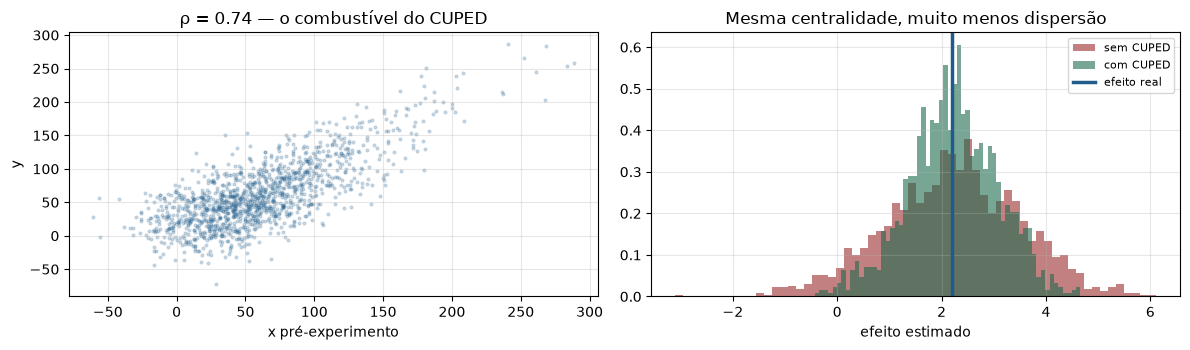

In [12]:
def cuped(y, x):
    theta = np.cov(y, x)[0, 1] / np.var(x, ddof=1)
    return y - theta * (x - x.mean()), theta


def ep_dif(valores, mascara):
    return np.sqrt(valores[mascara].var(ddof=1) / mascara.sum()
                   + valores[~mascara].var(ddof=1) / (~mascara).sum())


y_c, theta = cuped(y, x_pre)
rho = np.corrcoef(y, x_pre)[0, 1]

ep_sem, ep_com = ep_dif(y, tratado), ep_dif(y_c, tratado)
dif_sem = y[tratado].mean() - y[~tratado].mean()
dif_com = y_c[tratado].mean() - y_c[~tratado].mean()

painel("CUPED",
       theta=theta, correlacao=rho, reducao_teorica_rho2=rho**2,
       reducao_de_variancia_obtida=1 - y_c.var(ddof=1) / y.var(ddof=1),
       efeito_sem_cuped=dif_sem, efeito_com_cuped=dif_com,
       EP_sem=ep_sem, EP_com=ep_com,
       p_sem=2 * stats.norm.sf(abs(dif_sem / ep_sem)),
       p_com=2 * stats.norm.sf(abs(dif_com / ep_com)),
       trafego_equivalente_x=(ep_sem / ep_com) ** 2)

# não-viesamento, por simulação
estimativas = []
for s in range(1500):
    g = np.random.default_rng(s)
    niv = g.gamma(2.0, 30.0, 6000)
    xp = niv + g.normal(0, 25, 6000)
    tr = g.random(6000) < 0.5
    yy = niv + 2.2 * tr + g.normal(0, 25, 6000)
    yc, _ = cuped(yy, xp)
    estimativas.append([yy[tr].mean() - yy[~tr].mean(), yc[tr].mean() - yc[~tr].mean()])
estimativas = np.array(estimativas)

print(f"{'':<12s} {'média':>10s} {'viés':>10s} {'dp':>10s}")
print("-" * 46)
print(f"{'sem CUPED':<12s} {estimativas[:,0].mean():>10.4f} "
      f"{estimativas[:,0].mean()-2.2:>10.4f} {estimativas[:,0].std():>10.4f}")
print(f"{'com CUPED':<12s} {estimativas[:,1].mean():>10.4f} "
      f"{estimativas[:,1].mean()-2.2:>10.4f} {estimativas[:,1].std():>10.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].scatter(x_pre[::30], y[::30], s=4, alpha=0.2, color=AZUL)
axes[0].set_xlabel("x pré-experimento"); axes[0].set_ylabel("y")
axes[0].set_title(f"ρ = {rho:.2f} — o combustível do CUPED")
axes[1].hist(estimativas[:, 0], bins=60, alpha=0.6, color=VERMELHO, density=True,
             label="sem CUPED")
axes[1].hist(estimativas[:, 1], bins=60, alpha=0.6, color=VERDE, density=True,
             label="com CUPED")
axes[1].axvline(2.2, color=AZUL, lw=2.5, label="efeito real")
axes[1].set_xlabel("efeito estimado"); axes[1].legend(fontsize=8)
axes[1].set_title("Mesma centralidade, muito menos dispersão")
plt.tight_layout(); plt.show()

**A resposta ao item 4** é a coluna `trafego equivalente x`: o CUPED faz seus N
usuários renderem o mesmo que $N \times (EP_{sem}/EP_{com})^2$ usuários. Com
$\rho \approx 0{,}7$, isso é cerca de **2x** — dobrar o tráfego, sem gastar
nada.

**O detalhe de implementação que importa:** estime $\theta$ com os **dois
grupos juntos**. Estimar $\theta$ separadamente por grupo faz o ajuste depender
dos dados de cada braço e reintroduz viés — o mesmo erro do limiar de
winsorização por grupo, no exercício 4(e).

---
## Exercício 6 🔴 — Interferência: quando o A/B mente por construção

Em um marketplace com oferta limitada, dar destaque aos vendedores do grupo B
**rouba** vendas do grupo A. O experimento mede um efeito que não existiria se
a mudança fosse aplicada a todos.

1. Simule um marketplace com demanda total fixa.
2. Meça o "efeito" estimado por um A/B tradicional.
3. Compare com o efeito real de aplicar a mudança a **todos**.
4. Mostre que aleatorizar por **mercado** (cluster) resolve.

In [13]:
# --- sua resposta ---

### Gabarito 6

Marketplace com demanda fixa
----------------------------------------------------
lift medido pelo AB                         0.35246
lift real ao aplicar a todos                0.00000
vendas totais no AB                     60000.00000
vendas totais com todos                 60000.00000

aleatorização por MERCADO (40 clusters):
  lift estimado = +2.80%   p = 0.0000
  n efetivo = 40 clusters, não 2000 vendedores


/home/leo/excercicios-machine-learning/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:601: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


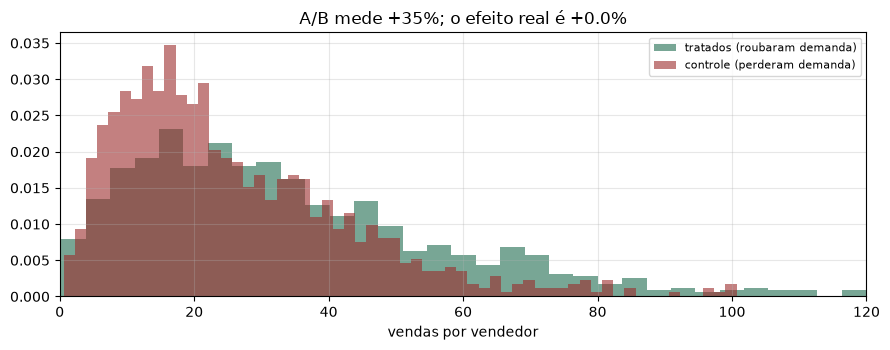

In [14]:
N_VENDEDORES, DEMANDA_TOTAL = 2_000, 60_000
BOOST = 1.35        # o destaque multiplica a atratividade do vendedor


def marketplace(fracao_tratada, semente=0):
    """Demanda total FIXA, distribuída proporcionalmente à atratividade."""
    g = np.random.default_rng(semente)
    atratividade = g.gamma(2.0, 1.0, N_VENDEDORES)
    tratado = g.random(N_VENDEDORES) < fracao_tratada
    efetiva = atratividade * np.where(tratado, BOOST, 1.0)
    vendas = DEMANDA_TOTAL * efetiva / efetiva.sum()      # soma zero: é um bolo fixo
    return vendas, tratado


# A/B tradicional: metade tratada
vendas_ab, trat_ab = marketplace(0.5, semente=1)
efeito_ab = vendas_ab[trat_ab].mean() / vendas_ab[~trat_ab].mean() - 1

# o que realmente acontece ao aplicar a TODOS: nada, a demanda é a mesma
vendas_todos, _ = marketplace(1.0, semente=1)
vendas_ninguem, _ = marketplace(0.0, semente=1)
efeito_real = vendas_todos.mean() / vendas_ninguem.mean() - 1

painel("Marketplace com demanda fixa",
       lift_medido_pelo_AB=efeito_ab,
       lift_real_ao_aplicar_a_todos=efeito_real,
       vendas_totais_no_AB=vendas_ab.sum(),
       vendas_totais_com_todos=vendas_todos.sum())

# aleatorização por MERCADO (cluster): cada mercado tem sua própria demanda
N_MERCADOS = 40
def mercado_isolado(tratado_flag, semente):
    g = np.random.default_rng(semente)
    atrat = g.gamma(2.0, 1.0, 50)
    efetiva = atrat * (BOOST if tratado_flag else 1.0)
    demanda = 1500 * (1.0 + 0.08 * (BOOST - 1) if tratado_flag else 1.0)  # efeito real pequeno
    return demanda * efetiva / efetiva.sum()


trat_mercado = np.arange(N_MERCADOS) % 2 == 0
vendas_por_mercado = np.array([mercado_isolado(trat_mercado[m], 100 + m).sum()
                               for m in range(N_MERCADOS)])
lift_cluster = (vendas_por_mercado[trat_mercado].mean()
                / vendas_por_mercado[~trat_mercado].mean() - 1)
t_cluster = stats.ttest_ind(vendas_por_mercado[trat_mercado],
                            vendas_por_mercado[~trat_mercado])

print(f"aleatorização por MERCADO ({N_MERCADOS} clusters):")
print(f"  lift estimado = {lift_cluster:+.2%}   p = {t_cluster.pvalue:.4f}")
print(f"  n efetivo = {N_MERCADOS} clusters, não 2000 vendedores")

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(vendas_ab[trat_ab], bins=60, alpha=0.6, color=VERDE, density=True,
        label="tratados (roubaram demanda)")
ax.hist(vendas_ab[~trat_ab], bins=60, alpha=0.6, color=VERMELHO, density=True,
        label="controle (perderam demanda)")
ax.set_xlabel("vendas por vendedor"); ax.set_xlim(0, 120)
ax.set_title(f"A/B mede {efeito_ab:+.0%}; o efeito real é {efeito_real:+.1%}")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

**O que aconteceu:** o A/B mediu um lift enorme, e o efeito real de aplicar a
mudança a todos é praticamente **zero**. As vendas totais são idênticas nos dois
cenários — o tratamento não criou demanda, apenas a redistribuiu do controle
para o tratamento.

**A suposição violada** chama-se SUTVA (*Stable Unit Treatment Value
Assumption*): o resultado de uma unidade não pode depender do tratamento das
outras. Ela é violada sempre que houver recurso compartilhado.

**Onde isso morde:**

| Domínio | Recurso disputado |
|---|---|
| marketplace / classificados | atenção e demanda dos compradores |
| leilão de anúncios | orçamento e inventário |
| rede social | feed de amigos em comum |
| entrega / mobilidade | motoristas e entregadores |
| e-mail marketing | tolerância do destinatário |

**As saídas:** aleatorizar por **cluster** (cidade, mercado, componente de grafo)
ou por **tempo** (switchback). Ambas custam poder — o $n$ efetivo passa a ser o
número de clusters, não de usuários — e é por isso que experimentos de
marketplace precisam de MDEs muito maiores.

---
## Exercício 7 🔴 — Desafio: a plataforma de experimentação

Escreva `analisa_experimento(df, metrica_primaria, guardrails, ...)` que
execute o protocolo completo e devolva um laudo com recomendação:

1. checagem de SRM (global e por segmento) — **abortando** se falhar;
2. balanceamento pré-experimento;
3. métrica primária com lift, IC e comparação ao MDE;
4. guardrails com teste unicaudal na direção do dano;
5. CUPED quando houver covariável pré-experimento;
6. segmentação com correção de FDR;
7. recomendação automática: **lançar / não lançar / estender**.

In [15]:
# --- sua resposta ---

### Gabarito 7

In [16]:
def analisa_experimento(df, metrica_primaria, guardrails=(), covariavel_pre=None,
                        segmentos=(), mde=0.03, alfa=0.05, alfa_srm=0.001):
    laudo = {"valido": True, "bloqueios": [], "alertas": []}
    print("=" * 76)
    print("LAUDO DE EXPERIMENTO".center(76))
    print("=" * 76)

    # ---- 1. SRM -----------------------------------------------------------
    print("\n[1] SANIDADE")
    cont = df["grupo"].value_counts().sort_index()
    p_srm = stats.chisquare(cont.values).pvalue
    print(f"    SRM global: {dict(cont)}  p = {p_srm:.4g}", end="  ")
    if p_srm < alfa_srm:
        print("-> SRM DETECTADO")
        laudo["valido"] = False
        laudo["bloqueios"].append("SRM global")
    else:
        print("-> OK")

    for seg in segmentos:
        for valor, bloco in df.groupby(seg):
            p = stats.chisquare(bloco["grupo"].value_counts().values).pvalue
            if p < alfa_srm:
                print(f"    SRM em {seg}={valor}: p = {p:.4g} -> QUEBRADO")
                laudo["valido"] = False
                laudo["bloqueios"].append(f"SRM em {seg}={valor}")

    if not laudo["valido"]:
        print("\n" + "!" * 76)
        print("EXPERIMENTO INVÁLIDO — não analise. Investigue a causa e refaça.".center(76))
        print("!" * 76)
        return laudo

    # ---- 2. balanceamento pré --------------------------------------------
    if covariavel_pre is not None:
        c = df.loc[df.grupo == "controle", covariavel_pre]
        t = df.loc[df.grupo == "tratamento", covariavel_pre]
        p_bal = stats.ttest_ind(c, t, equal_var=False).pvalue
        print(f"\n[2] BALANCEAMENTO PRÉ-EXPERIMENTO")
        print(f"    {covariavel_pre}: {c.mean():.4f} vs {t.mean():.4f}  p = {p_bal:.4f}", end="  ")
        print("-> OK" if p_bal >= 0.01 else "-> DESBALANCEADO")
        if p_bal < 0.01:
            laudo["alertas"].append("covariável pré-experimento desbalanceada")

    # ---- 3. métrica primária (com CUPED se possível) ----------------------
    print(f"\n[3] MÉTRICA PRIMÁRIA — {metrica_primaria}")
    trat = (df.grupo == "tratamento").values
    y = df[metrica_primaria].values.astype(float)

    def resumo(vals):
        d = vals[trat].mean() - vals[~trat].mean()
        ep = np.sqrt(vals[trat].var(ddof=1) / trat.sum()
                     + vals[~trat].var(ddof=1) / (~trat).sum())
        return d, ep

    dif, ep = resumo(y)
    usou_cuped = False
    if covariavel_pre is not None:
        x = df[covariavel_pre].values.astype(float)
        rho = np.corrcoef(y, x)[0, 1]
        if abs(rho) > 0.3:
            theta = np.cov(y, x)[0, 1] / np.var(x, ddof=1)
            dif, ep = resumo(y - theta * (x - x.mean()))
            usou_cuped = True
            print(f"    CUPED aplicado (ρ = {rho:.3f}, redução de variância ≈ {rho**2:.0%})")

    base = y[~trat].mean()
    z = dif / ep
    p = 2 * stats.norm.sf(abs(z))
    ic = dif + np.array([-1, 1]) * stats.norm.isf(alfa / 2) * ep
    lift, ic_lift = dif / base, ic / base

    print(f"    controle {base:.5f}   tratamento {y[trat].mean():.5f}")
    print(f"    lift {lift:+.2%}   IC95 [{ic_lift[0]:+.2%}, {ic_lift[1]:+.2%}]")
    print(f"    p = {p:.5g}   MDE declarado = {mde:+.1%}   "
          f"{'CUPED' if usou_cuped else 'sem CUPED'}")
    laudo.update({"lift": lift, "ic_lift": ic_lift, "p": p})

    # ---- 4. guardrails ----------------------------------------------------
    print(f"\n[4] GUARDRAILS")
    guardrail_quebrado = False
    for nome, direcao_ruim, limite in guardrails:
        c = df.loc[df.grupo == "controle", nome]
        t = df.loc[df.grupo == "tratamento", nome]
        rel = t.mean() / c.mean() - 1
        alt = "greater" if direcao_ruim == "aumenta" else "less"
        pg = stats.ttest_ind(t, c, equal_var=False, alternative=alt).pvalue
        ruim = (rel > limite) if direcao_ruim == "aumenta" else (rel < -limite)
        estado = "DEGRADOU" if (pg < 0.05 and ruim) else ("atenção" if pg < 0.05 else "OK")
        print(f"    {nome:<26s} {rel:+7.2%}  p = {pg:<9.4g} {estado}")
        if estado == "DEGRADOU":
            guardrail_quebrado = True
            laudo["bloqueios"].append(f"guardrail {nome}")

    # ---- 5. segmentação com FDR ------------------------------------------
    if segmentos:
        print(f"\n[5] SEGMENTAÇÃO (correção FDR)")
        linhas = []
        for seg in segmentos:
            for valor, bloco in df.groupby(seg):
                m = (bloco.grupo == "tratamento").values
                v = bloco[metrica_primaria].values.astype(float)
                if m.sum() < 30 or (~m).sum() < 30:
                    continue
                d = v[m].mean() - v[~m].mean()
                e = np.sqrt(v[m].var(ddof=1) / m.sum() + v[~m].var(ddof=1) / (~m).sum())
                linhas.append({"segmento": f"{seg}={valor}", "n": len(bloco),
                               "lift": d / v[~m].mean(), "p": 2 * stats.norm.sf(abs(d / e))})
        if linhas:
            s = pd.DataFrame(linhas).sort_values("p").reset_index(drop=True)
            limiar = alfa * (s.index + 1) / len(s)
            abaixo = np.where(s["p"].values <= limiar)[0]
            s["signif_FDR"] = False
            if len(abaixo):
                s.loc[: abaixo[-1], "signif_FDR"] = True
            print(s.round(4).to_string(index=False))
            if not s["signif_FDR"].any():
                print("    nenhuma heterogeneidade sobrevive à correção — efeito homogêneo")

    # ---- 6. recomendação --------------------------------------------------
    print(f"\n[6] RECOMENDAÇÃO")
    if guardrail_quebrado:
        decisao = "NÃO LANÇAR — guardrail degradado"
    elif p >= alfa and ic_lift[1] < mde:
        decisao = "NÃO LANÇAR — efeito descartado abaixo do MDE"
    elif p >= alfa:
        decisao = "ESTENDER — inconclusivo, o IC ainda cobre o MDE"
    elif ic_lift[0] >= mde:
        decisao = "LANÇAR — efeito supera o MDE com folga"
    elif lift > 0:
        decisao = "LANÇAR COM RESSALVA — efeito positivo, mas pode estar abaixo do MDE"
    else:
        decisao = "NÃO LANÇAR — efeito negativo"
    print(f"    {decisao}")
    laudo["decisao"] = decisao
    print("=" * 76)
    return laudo


# --- dados de teste ---------------------------------------------------------
N = 80_000
df = pd.DataFrame({
    "grupo": rng.choice(["controle", "tratamento"], N),
    "plataforma": rng.choice(["iOS", "Android", "Web"], N, p=[0.3, 0.45, 0.25]),
})
nivel = rng.gamma(2.0, 20.0, N)
df["receita_mes_anterior"] = nivel + rng.normal(0, 18, N)
df["receita"] = (nivel + 1.9 * (df.grupo == "tratamento") + rng.normal(0, 18, N))
df["tempo_ms"] = rng.lognormal(np.log(600), 0.3, N) + 30 * (df.grupo == "tratamento")
df["erro"] = rng.random(N) < 0.005

laudo = analisa_experimento(
    df, metrica_primaria="receita",
    guardrails=[("tempo_ms", "aumenta", 0.05), ("erro", "aumenta", 0.10)],
    covariavel_pre="receita_mes_anterior",
    segmentos=["plataforma"], mde=0.03)

                            LAUDO DE EXPERIMENTO                            

[1] SANIDADE
    SRM global: {'controle': np.int64(40143), 'tratamento': np.int64(39857)}  p = 0.3119  -> OK

[2] BALANCEAMENTO PRÉ-EXPERIMENTO
    receita_mes_anterior: 40.0809 vs 40.2101  p = 0.5858  -> OK

[3] MÉTRICA PRIMÁRIA — receita
    CUPED aplicado (ρ = 0.710, redução de variância ≈ 50%)
    controle 39.97980   tratamento 42.09212
    lift +5.05%   IC95 [+4.24%, +5.87%]
    p = 9.4259e-34   MDE declarado = +3.0%   CUPED

[4] GUARDRAILS
    tempo_ms                    +4.78%  p = 7.444e-108 atenção
    erro                       -11.13%  p = 0.8859    OK

[5] SEGMENTAÇÃO (correção FDR)
          segmento     n   lift   p  signif_FDR
plataforma=Android 35840 0.0535 0.0        True
    plataforma=iOS 24090 0.0543 0.0        True
    plataforma=Web 20070 0.0499 0.0        True

[6] RECOMENDAÇÃO
    LANÇAR — efeito supera o MDE com folga


**Por que a função aborta em SRM antes de qualquer outra coisa:** analisar um
experimento inválido não é só inútil — é ativamente danoso, porque produz um
número que alguém vai usar. A plataforma tem que tornar impossível pular essa
etapa.

**Por que a recomendação distingue "não lançar" de "estender":** um resultado
não-significativo cujo IC ainda cobre o MDE é **inconclusivo**, não negativo.
Tratar os dois como a mesma coisa mata hipóteses boas por falta de amostra —
o erro tipo II saindo caro sem que ninguém perceba.

**O que uma plataforma real acrescentaria:** monitoramento sequencial com
fronteiras válidas, detecção automática de efeito novidade (lift por semana),
alertas de guardrail em tempo real, e um registro imutável do protocolo
declarado **antes** do início — para que ninguém possa reescrever a métrica
primária depois.

---
## Fechamento

- **Dimensione antes.** MDE é decisão de negócio; o custo cresce com $1/\Delta^2$.
- **SRM primeiro, sempre.** Sem conserto, sem reponderação, sem exceção.
- **Espiar sem correção leva o erro tipo I a ~25%.** Duração fixa ou fronteira
  sequencial.
- **A unidade de análise é a de aleatorização.** ITT por padrão.
- **CUPED com covariável pré-aleatorização** dobra o tráfego efetivo de graça.
- **Interferência quebra o A/B por construção** em marketplaces — aleatorize
  por cluster ou por tempo.
- **Guardrails e protocolo declarado antes** são o que separa uma plataforma de
  experimentação de uma máquina de fabricar descobertas.

→ Fim do tema **Estatística**. Próximo tema: **Álgebra Linear e Otimização** —
a maquinaria que faz os modelos funcionarem.